Data organized as a Numpy matrix where each row corresponds to an observation or as list of lists:

In [21]:
data = [[ 0.80,  0.55,  0.22,  0.03],
        [ 0.82,  0.50,  0.23,  0.03],
        [ 0.80,  0.54,  0.22,  0.03],
        [ 0.80,  0.53,  0.26,  0.03],
        [ 0.79,  0.56,  0.22,  0.03],
        [ 0.75,  0.60,  0.25,  0.03],
        [ 0.77,  0.59,  0.22,  0.03]]      

Train MiniSom:

In [22]:
from minisom import MiniSom    
som = MiniSom(6, 6, 4, sigma=0.3, learning_rate=0.5) # initialization of 6x6 SOM
som.train(data, 100) # trains the SOM with 100 iterations

Obtain the position of the winning neuron on the map:

In [23]:
som.winner(data[0])

(4, 2)

Other example:

In [24]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  # Install Intrasom
  !pip install minisom

LOCAL_DEV = False
if LOCAL_DEV:
    sys.path.insert(0, '../')
    %load_ext autoreload


In [25]:
from minisom import MiniSom
import pandas as pd
import numpy as np
columns=['area', 'perimeter', 'compactness', 'length_kernel', 'width_kernel',
                   'asymmetry_coefficient', 'length_kernel_groove', 'target']
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt', 
                    names=columns, 
                   sep='\t+', engine='python')
target = data['target'].values

#print(target)
label_names = {1:'Kama', 2:'Rosa', 3:'Canadian'}
data = data[data.columns[:-1]]
# data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

In [26]:
# Initialization and training
n_neurons = 9
m_neurons = 9

print(np.isnan(data).any())
print(np.isinf(data).any())
print(data.dtype)
print(data.shape[1])

som = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

som.pca_weights_init(data)
som.train(data, 1000, verbose=True)  # random training

False
False
float64
7
 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.506671895909233


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [8]:
som.topographic_error(data[:100])

0.08

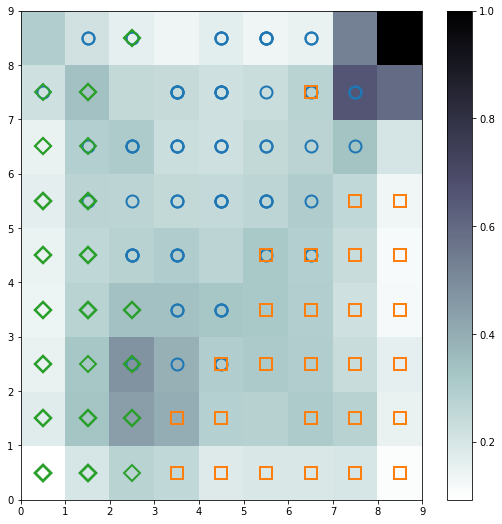

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(9, 9))

plt.pcolor(som.distance_map().T, cmap='bone_r')  # plotting the distance map as background
plt.colorbar()

# Plotting the response for each pattern in the iris dataset
# different colors and markers for each label
markers = ['o', 's', 'D']
colors = ['C0', 'C1', 'C2']
for cnt, xx in enumerate(data):
    w = som.winner(xx)  # getting the winner
    # palce a marker on the winning position for the sample xx
    plt.plot(w[0]+.5, w[1]+.5, markers[target[cnt]-1], markerfacecolor='None',
             markeredgecolor=colors[target[cnt]-1], markersize=12, markeredgewidth=2)

plt.show()

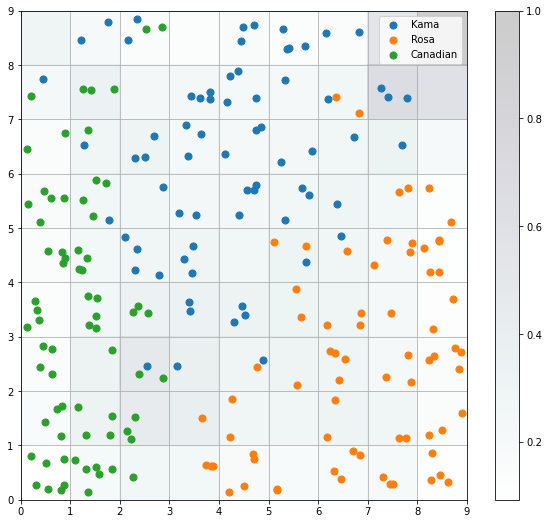

In [10]:


w_x, w_y = zip(*[som.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1], label=label_names[c])
plt.legend(loc='upper right')
plt.grid()
plt.show()



In [8]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
columns = ['Key','RShoulderPitch', 'RShoulderRoll', 'RElbowYaw', 'RElbowRoll']
data = pd.read_csv('motor_angles.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(data)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
#print(data)
# Data normalization
#data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values
#print(data)
#print(np.isnan(data).any())
#print(np.isinf(data).any())
#print(data.dtype)
#print(data.shape[1])

# Initialization and training
n_neurons = 5
m_neurons = 5

somAngles = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

somAngles.pca_weights_init(data)
somAngles.train(data, 1000, verbose=True)  # random training

# Get the Euclidean distance between the coordinate and each neuron's weight vector
distance_map = somAngles.distance_map()

print(distance_map)

# Find the index of the neuron with the minimum distance to the coordinate
bmu_index = np.unravel_index(np.argmin(distance_map), distance_map.shape)

# Get the Euclidean distance between the coordinate and the BMU
bmu_distance = distance_map[bmu_index]

# Print the Euclidean distance
print("Euclidean distance to BMU:", bmu_distance)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.5993207059242269
[[0.33630599 0.61977029 0.55963478 0.57375273 0.36839023]
 [0.64561156 1.         0.95647701 0.93145253 0.58540288]
 [0.60308735 0.99278133 0.92765508 0.85095531 0.53938213]
 [0.54608909 0.93535341 0.87319786 0.82095741 0.55392514]
 [0.30002052 0.60088549 0.51807172 0.4837245  0.34263804]]
Euclidean distance to BMU: 0.3000205152662668


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


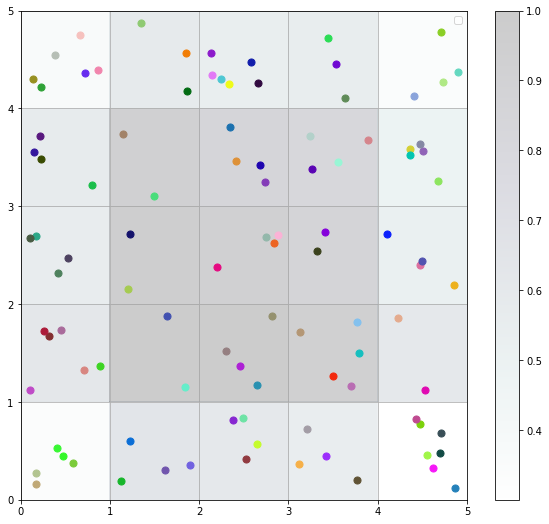

In [35]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, 100)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(100)]

#plot som
w_x, w_y = zip(*[somAngles.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(somAngles.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()


In [36]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
columns = ['Key','X', 'Y', 'Z']
data = pd.read_csv('gps_hand.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

# Initialization and training
n_neurons = 5
m_neurons = 5

print(np.isnan(data).any())
print(np.isinf(data).any())
print(data.dtype)
print(data.shape[1])

somVisual = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

somVisual.pca_weights_init(data)
somVisual.train(data, 1000, verbose=True)  # random training


False
False
float64
3
 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.4685025007207054


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


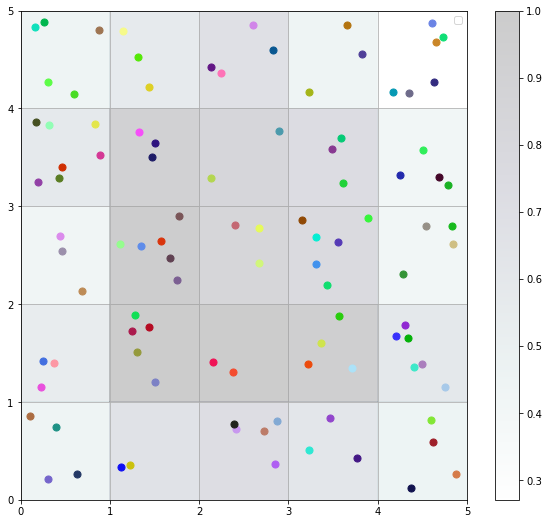

In [37]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, 100)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(100)]

#plot som
w_x, w_y = zip(*[somVisual.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(somVisual.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [38]:
import pickle
with open('somAngles.p', 'wb') as outfile:
    pickle.dump(somAngles, outfile)

In [39]:
import pickle
with open('somVisual.p', 'wb') as outfile:
    pickle.dump(somAngles, outfile)

In [5]:
import csv

motor_data = []
gps_data = []

# Leer los angulos de los motores del CSV
with open("motor_angles.csv", "r", newline='') as motor_csvfile:
    motor_reader = csv.reader(motor_csvfile)
    next(motor_reader)  # Pasar el encabezado
    for row in motor_reader:
        motor_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice

# Leer los datos del GPS del CSV
with open("gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
    next(gps_reader)  # Pasar el encabezado
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice

print(somVisual.winner(random.choice(gps_data)));

# Obtener todas las coordinadas del som visual
visual_coordinates = [somVisual.winner(entry) for entry in gps_data]
# Obtener todas las coordinadas del som motor
motor_coordinates = [somAngles.winner(entry) for entry in motor_data]

print("Visual coordinates:", visual_coordinates)
print("Motor coordinates:", motor_coordinates)
# Crear un nuevo conjunto de datos que consiste en todas las combinaciones de las coordenadas
#combined_dataset = [(visual_coord, motor_coord) for visual_coord, motor_coord in zip(visual_coordinates, motor_coordinates)]
combined_dataset = []

for visual_coord, motor_coord in zip(visual_coordinates, motor_coordinates):
    combined_entry = visual_coord + motor_coord  # Concatenate the two coordinate vectors
    combined_dataset.append(combined_entry)

combined_dataset= pd.DataFrame(combined_dataset)
combined_dataset=combined_dataset.values

#print(type(combined_dataset))
#print(combined_dataset)
#print(combined_dataset.shape[1])

#Initialization and training
n_neurons_combined = 5
m_neurons_combined = 5


somCombined = MiniSom(n_neurons_combined, m_neurons_combined, combined_dataset.shape[1], sigma=1.5, learning_rate=.5, 
                  neighborhood_function='gaussian', random_seed=0, topology='rectangular')
    
somCombined.pca_weights_init(combined_dataset)
somCombined.train(combined_dataset, 1000, verbose=True)  # random training

#print(somCombined.winner(random.choice(combined_dataset)));


NameError: name 'somVisual' is not defined

In [4]:
from minisom import MiniSom
import numpy as np

# Create a MiniSom object
som = MiniSom(10, 10, input_len=2)  # 10x10 grid, input vectors of length 2

# Generate some random training data
data = np.random.rand(100, 2)  # 100 data points, each with 2 dimensions
#print(data)
# Initialize the SOM's weights randomly
som.random_weights_init(data)

# Train the SOM
som.train_random(data, 100)  # Train for 100 iterations

# Define a coordinate
coordinate = np.array([0.5, 0.5])

# Get the Euclidean distance between the coordinate and each neuron's weight vector
distance_map = som.distance_map()

print(distance_map)
# Find the index of the neuron with the minimum distance to the coordinate
bmu_index = np.unravel_index(np.argmin(distance_map), distance_map.shape)

# Get the Euclidean distance between the coordinate and the BMU
bmu_distance = distance_map[bmu_index]

# Print the Euclidean distance
print("Euclidean distance to BMU:", bmu_distance)


[[0.25978139 0.64477826 0.48376841 0.29176181 0.46101792 0.28270296
  0.52835011 0.34182085 0.37075081 0.25804409]
 [0.35668389 0.68537944 0.6327455  0.56805005 0.49977158 0.47523492
  0.43946068 0.87375522 0.73633514 0.53359865]
 [0.20001997 0.44611821 0.67929976 0.76545423 0.56077344 0.51025044
  0.42708809 0.69579962 0.97321788 0.51573373]
 [0.39485675 1.         0.64156719 0.86634482 0.94836377 0.37544295
  0.59249867 0.80882829 0.75091974 0.48776086]
 [0.56291618 0.59390985 0.76504828 0.75067919 0.70782368 0.61261247
  0.42433938 0.63112934 0.80352376 0.52585183]
 [0.27304398 0.4778245  0.63159833 0.78204356 0.84933614 0.58467828
  0.61334788 0.69580604 0.7634483  0.85116087]
 [0.34390699 0.68347239 0.66659943 0.61785315 0.86706544 0.73196607
  0.52798141 0.75242594 0.72850808 0.52540855]
 [0.40166731 0.45295577 0.52403649 0.67706311 0.66668783 0.75566946
  0.77030942 0.63520315 0.90140945 0.36467179]
 [0.51945845 0.65359146 0.61167894 0.57251589 0.73357485 0.63935373
  0.70706979